In [2]:
data_dir = "../../temperature_check"

In [4]:
!python -m pip install pandas

  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 143.1 MB/s  0:00:00
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]


In [5]:
import json
import os
import re
import matplotlib.pyplot as plt
import pandas as pd
from typing import List, Tuple


In [6]:
def extract_temperature_from_filename(filename: str) -> float:
    """
    Extract temperature from filename using regex.
    
    Expected pattern: tool-calling-surgical_adapter_v27_qwen3_8b_step_15_modified_template-{temp}_range_0--1_user-qwen25-32b-llm_{timestamp}.json
    """
    pattern = r"tool-calling-surgical_adapter_v27_qwen3_8b_step_\d+_[^-]+-([0-9]*\.?[0-9]+)_range_0--?1_user-.*-llm_\d+\.json"
    match = re.search(pattern, filename)
    
    if match:
        return float(match.group(1))
    else:
        raise ValueError(f"Could not extract temperature from filename: {filename}")

def calculate_average_reward(json_file_path: str) -> float:
    """
    Calculate the average reward from a JSON file containing a list of objects with 'reward' keys.
    """
    with open(json_file_path, 'r') as f:
        data = json.load(f)
    
    if not data:
        return 0.0
    
    total_reward = sum(item['reward'] for item in data)
    return total_reward / len(data)


In [7]:
def process_data_directory(data_dir: str) -> Tuple[List[float], List[float]]:
    """
    Process all JSON files in the data directory and extract temperature-performance pairs.
    
    Returns:
        Tuple of (temperatures, average_rewards)
    """
    temperatures = []
    avg_rewards = []
    
    # Get all JSON files in the directory
    json_files = [f for f in os.listdir(data_dir) if f.endswith('.json')]
    
    for filename in json_files:
        try:
            # Extract temperature from filename
            temperature = extract_temperature_from_filename(filename)
            
            # Calculate average reward
            file_path = os.path.join(data_dir, filename)
            avg_reward = calculate_average_reward(file_path)
            
            temperatures.append(temperature)
            avg_rewards.append(avg_reward)
            
            print(f"Processed {filename}: temp={temperature}, avg_reward={avg_reward:.4f}")
            
        except Exception as e:
            print(f"Error processing {filename}: {e}")
            continue
    
    return temperatures, avg_rewards

def plot_performance_vs_temperature(data_dir: str, save_plot: bool = False, plot_filename: str = "performance_vs_temperature.png"):
    """
    Create a line plot showing performance vs temperature.
    """
    temperatures, avg_rewards = process_data_directory(data_dir)
    
    if not temperatures:
        print("No valid data found to plot!")
        return
    
    # Create DataFrame for easier sorting
    df = pd.DataFrame({'temperature': temperatures, 'avg_reward': avg_rewards})
    df = df.sort_values('temperature')
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(df['temperature'], df['avg_reward'], marker='o', linewidth=2, markersize=8)
    plt.xlabel('Temperature', fontsize=12)
    plt.ylabel('Average Reward (Performance)', fontsize=12)
    plt.title('Performance vs Temperature', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Add value labels on points
    for i, row in df.iterrows():
        plt.annotate(f'{row["avg_reward"]:.3f}', 
                    (row['temperature'], row['avg_reward']), 
                    textcoords="offset points", 
                    xytext=(0,10), 
                    ha='center', fontsize=9)
    
    plt.tight_layout()
    
    if save_plot:
        plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
        print(f"Plot saved as {plot_filename}")
    
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary:")
    print(f"Number of data points: {len(df)}")
    print(f"Temperature range: {df['temperature'].min():.2f} - {df['temperature'].max():.2f}")
    print(f"Performance range: {df['avg_reward'].min():.4f} - {df['avg_reward'].max():.4f}")
    print(f"Best performance: {df['avg_reward'].max():.4f} at temperature {df.loc[df['avg_reward'].idxmax(), 'temperature']}")
    
    return df


Processed tool-calling-surgical_adapter_v27_qwen3_8b_step_15_modified_template-1.2_range_0--1_user-qwen25-32b-llm_0927102810.json: temp=1.2, avg_reward=0.3511
Processed tool-calling-surgical_adapter_v27_qwen3_8b_step_15_modified_template-0.9_range_0--1_user-qwen25-32b-llm_0927043436.json: temp=0.9, avg_reward=0.3378
Processed tool-calling-surgical_adapter_v27_qwen3_8b_step_15_modified_template-0.8_range_0--1_user-qwen25-32b-llm_0927023242.json: temp=0.8, avg_reward=0.3394
Processed tool-calling-surgical_adapter_v27_qwen3_8b_step_15_modified_template-1.8_range_0--1_user-qwen25-32b-llm_0927215329.json: temp=1.8, avg_reward=0.3519
Processed tool-calling-surgical_adapter_v27_qwen3_8b_step_15_modified_template-1.6_range_0--1_user-qwen25-32b-llm_0927180804.json: temp=1.6, avg_reward=0.3524
Processed tool-calling-surgical_adapter_v27_qwen3_8b_step_15_modified_template-0.6_range_0--1_user-qwen25-32b-llm_0926215658.json: temp=0.6, avg_reward=0.3122
Processed tool-calling-surgical_adapter_v27_qw

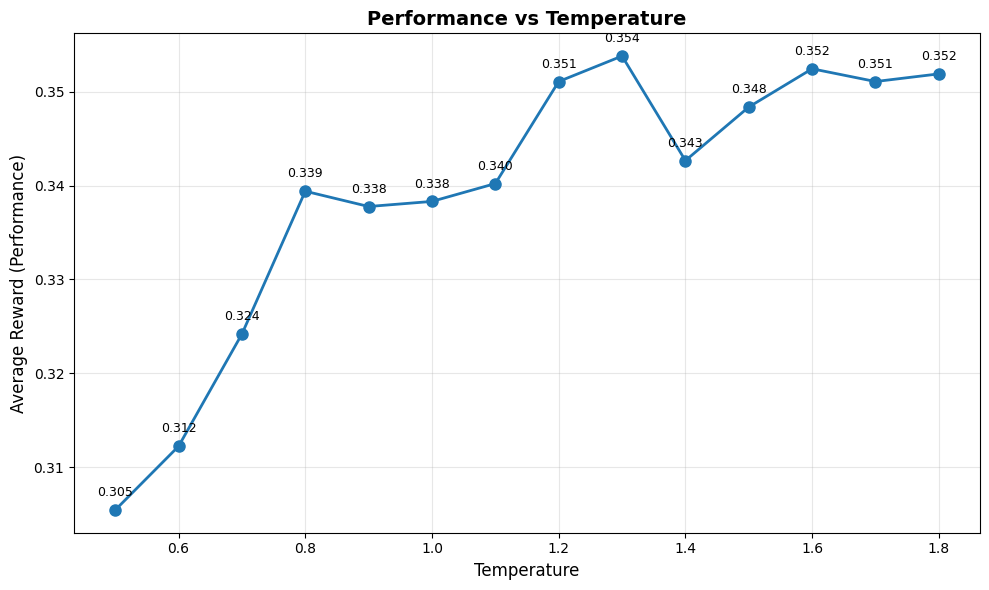


Summary:
Number of data points: 14
Temperature range: 0.50 - 1.80
Performance range: 0.3054 - 0.3538
Best performance: 0.3538 at temperature 1.3


,temperature,avg_reward
13,0.5,0.305435
5,0.6,0.312228
6,0.7,0.324185
2,0.8,0.339402
1,0.9,0.337772
12,1.0,0.338315
8,1.1,0.340217
0,1.2,0.351087
9,1.3,0.353804
11,1.4,0.342663


In [9]:
# Example usage:
# Uncomment and run the line below to create the plot
plot_performance_vs_temperature(data_dir, save_plot=False)

# For testing with a specific directory, you can also use:
# plot_performance_vs_temperature("../../results/your_specific_directory", save_plot=True)
